## Categorising countries

### Data Source

The data used in this task was orginally sourced from Help.NGO. This international non-governmental organisation specialises in emergency response, preparedness, and risk mitigation.  

### Dataset Attributes
- country: name of the country
- child_mort: death of children under 5 years of age per 1000 live births
- exports: exports of goods and services per capita. Given as a percentage of the GDP per capita
- health: total health spending per capita. Given as a percentage of GDP per capita
- imports: imports of goods and services per capita. Given as a percentage of the GDP per capita
- income: net income per person
- inflation: the measurement of the annual growth rate of the Total GDP
- life_expec: the average number of years a new born child would live if the current mortality patterns remain the same
- total_fer: the number of children that would be born to each woman if the current age-fertility rates remains the same
- gdpp: the GDP per capita. Calculated as the Total GDP divided by the total population.

## Objective  
To group countries using socio-economic and health factors to determine the development status of the country.

In [64]:
# Import libraries
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore', 
                        category=FutureWarning)
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [65]:
# Random state seed
rseed = 42

## Load and explore data

In [66]:
# Import the dataset and show first 5 rows
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [67]:
# Check the shape using .shape
# The output will be in the format (rows, columns)
print(df.shape)

(167, 10)


In [68]:
# Check datatypes & counts
# To check the datatypes and counts, dtypes can be used
print(df.dtypes)

# To check for counts, info() can be used
print(df.info())

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [69]:
# Get descriptive statistics
# To get the descriptive statistics, describe() can be used
# Instead of having to determine each of the statistics separately
print(df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.795000    1330.000000

In [70]:
# Identify any missing data
print(df.isnull().sum(), end='\n\n')

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64



## Preprocessing and Feature Selection

In [ ]:
# Drop any non-numeric features (columns)
drop_cols = ['country']

# Store the country column in a separate variable
# Which allows it to be used later if needed
Y = df['country']
X = df.drop(drop_cols, axis=1)

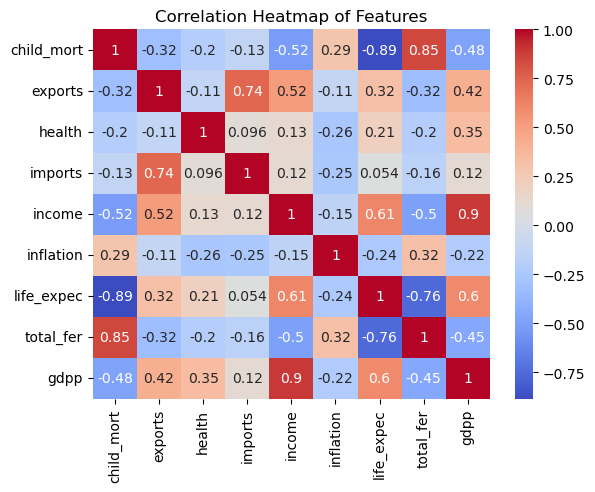

In [72]:
# Create a correlation map of features to explore relationships
# between features
# Hint: Explore seaborn heatmap

# Create a correlation map of features to explore relationships 
# Using the X variable and .corr
correlation_map = X.corr()

plt.figure()
sns.heatmap(correlation_map, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

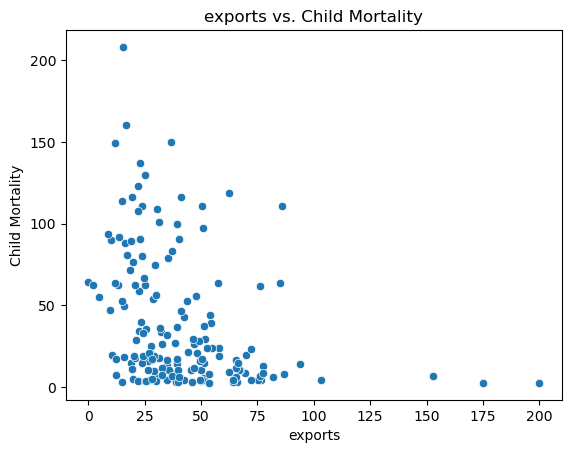

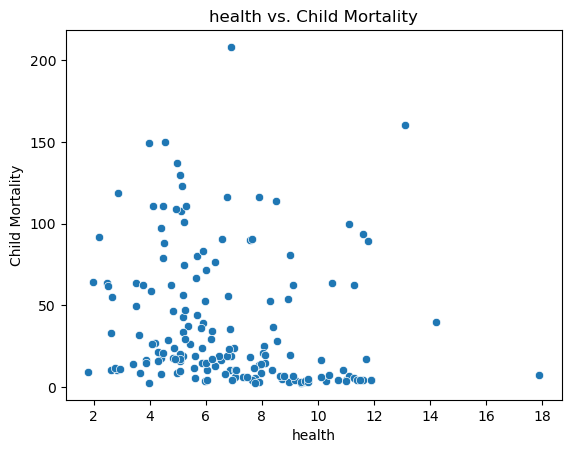

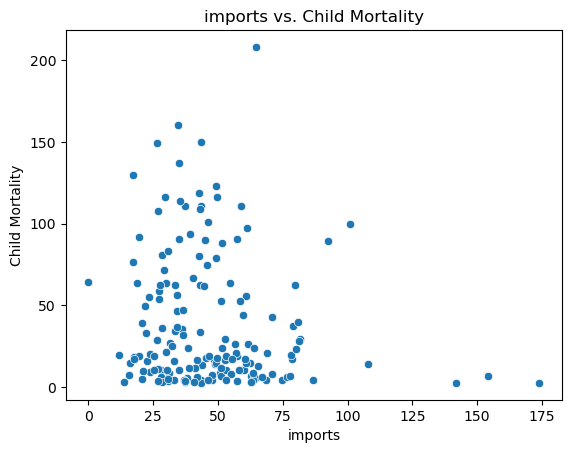

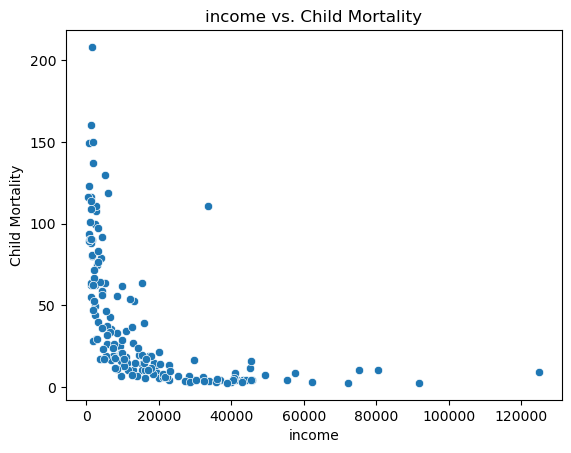

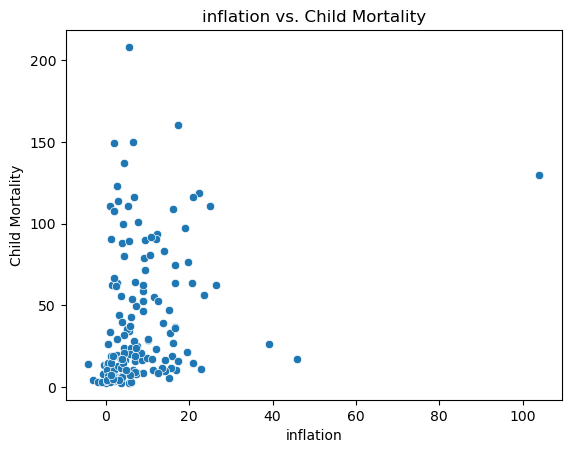

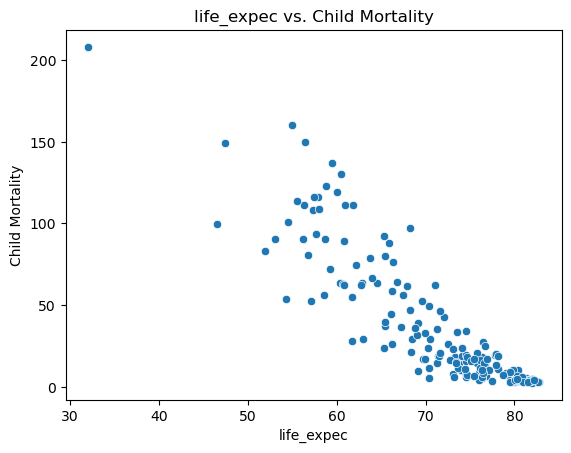

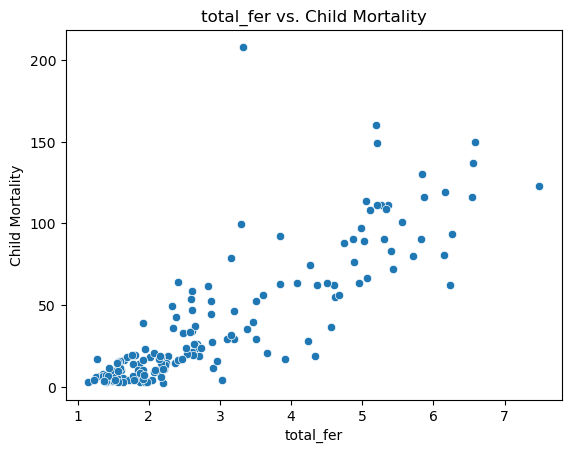

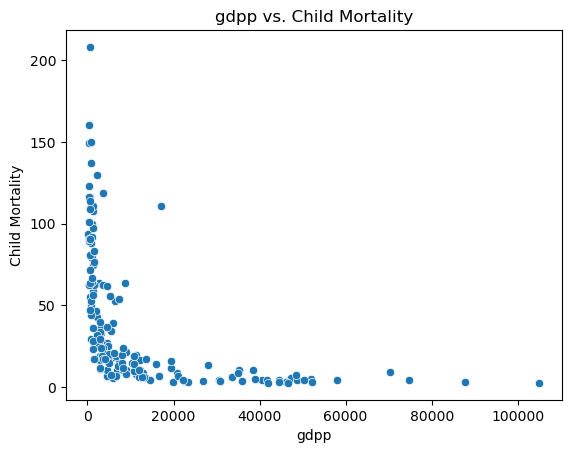

In [ ]:
# Explore the continuous independent features against 
# child_mort using scatter plots.
# Plot a scatter plot using the X variable
continuous_independent_features =   X.columns.tolist()
continuous_independent_features.remove('child_mort')

# Make use of a for loop to iterate through 
# The continuous_independent_features to plot different 
# Scatter plots for each feature
for feature in continuous_independent_features:
    plt.figure()
    sns.scatterplot(x=feature, y='child_mort', data=df)
    plt.title(f'{feature} vs. Child Mortality')
    plt.xlabel(feature)
    plt.ylabel('Child Mortality')
    plt.show()

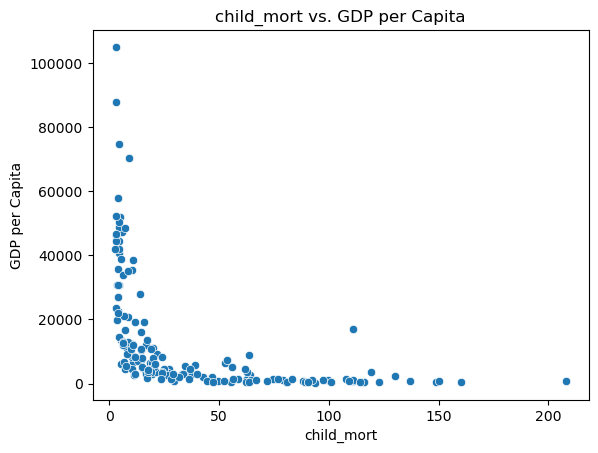

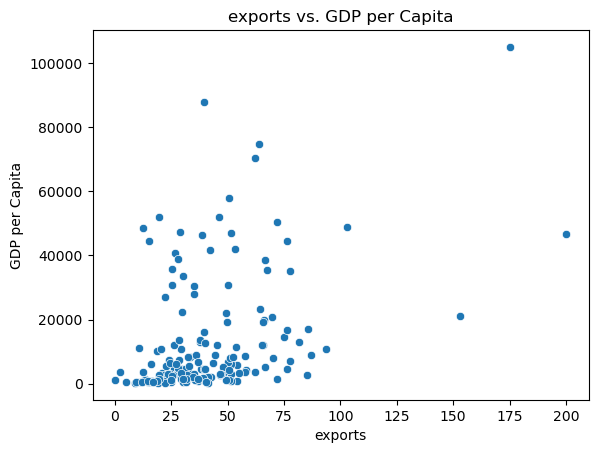

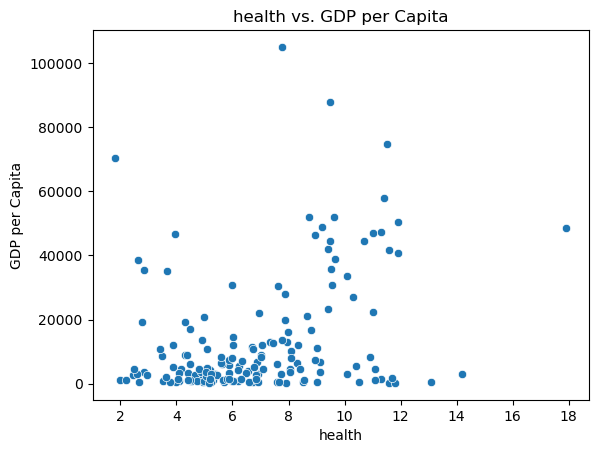

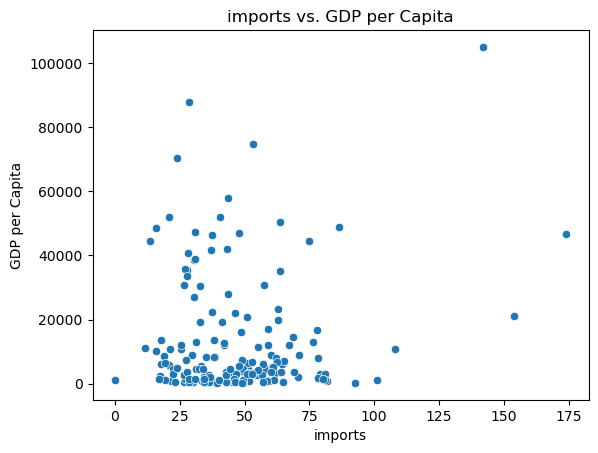

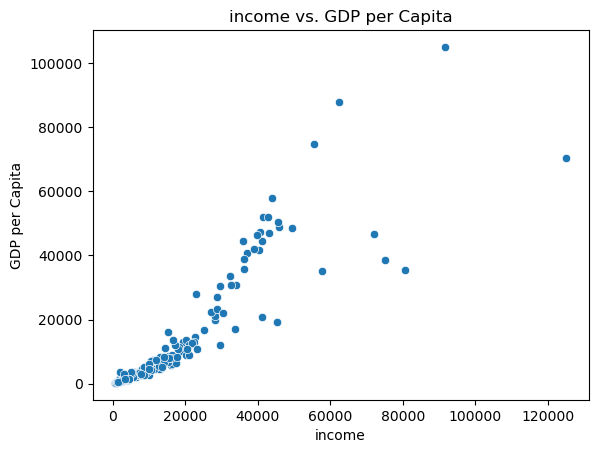

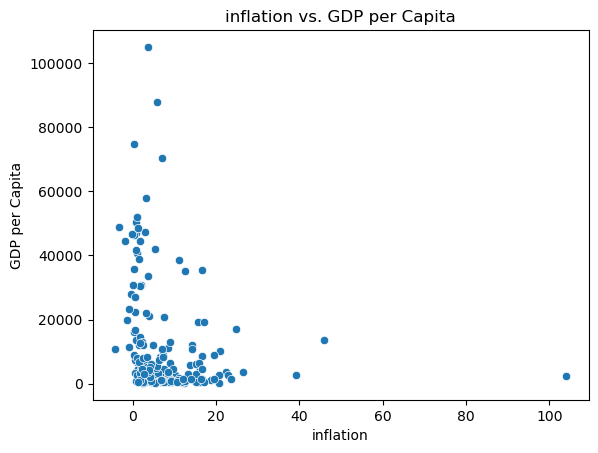

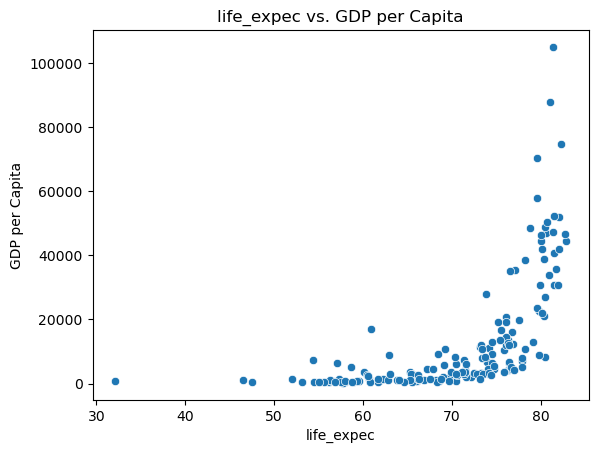

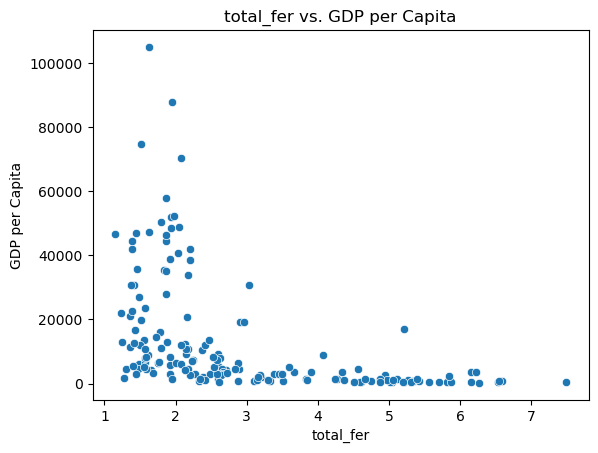

In [ ]:
# Explore the continuous independent features against gdpp using scatter plots.
# Plot a scatter plot using the X variable
continuous_independent_features =   X.columns.tolist()
continuous_independent_features.remove('gdpp')

# Make use of a for loop to iterate through 
# The continuous_independent_features to plot different 
# Scatter plots for each feature
for feature in continuous_independent_features:
    plt.figure()
    sns.scatterplot(x=feature, y='gdpp', data=df)
    plt.title(f'{feature} vs. GDP per Capita')
    plt.xlabel(feature)
    plt.ylabel('GDP per Capita')
    plt.show()

<Figure size 640x480 with 0 Axes>

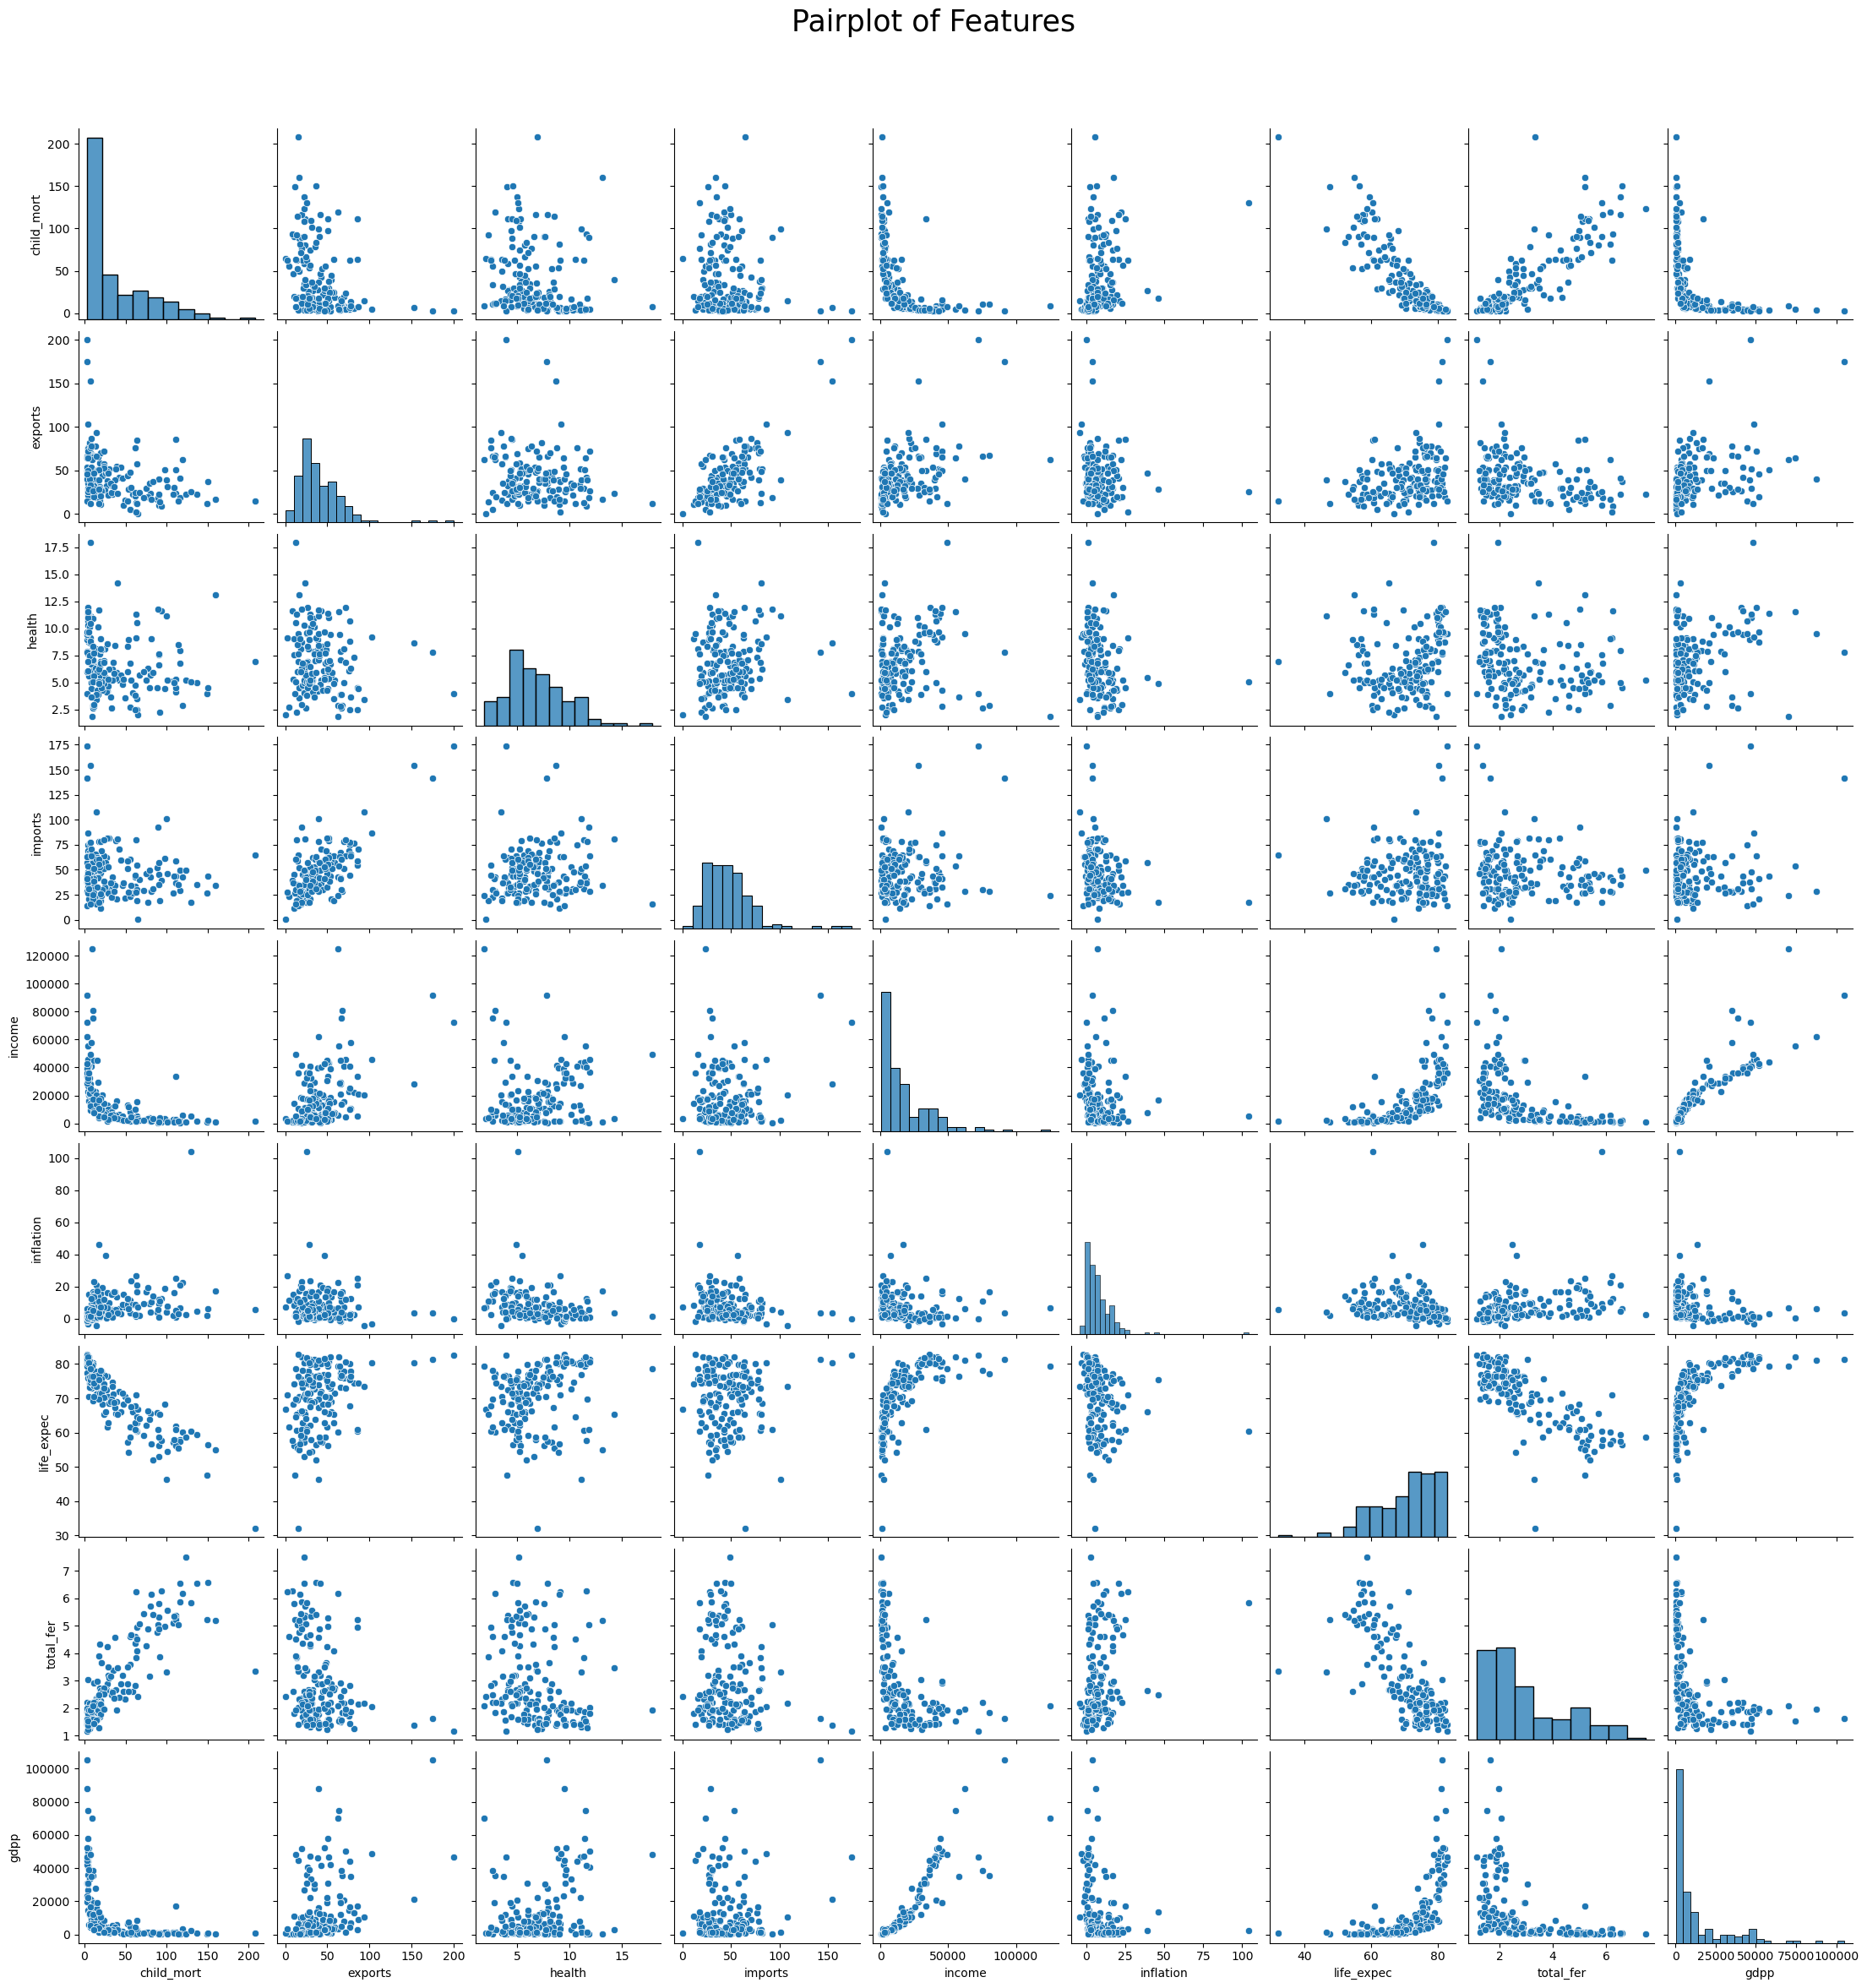

In [75]:
# Create a pair plot
# Hint: Explore seaborn pairplot

# After trying to use plt.title and plt.title, it was not working
# as expected. After doing research it was found that these labels
# do not function normally on pairplots. I recall learning about 
# Pairplots, so I revised Level 2 visualisation tasks for guidance. 
plt.figure()
fg = sns.pairplot(X)
fg.figure.suptitle('Pairplot of Features', y=1.05, fontsize=25)
plt.show()

Note the peaks in the diagonal graphs that are distinct from each other or only overlap slightly. Looking at the scatter plot distributions may also give you some indication of features that would be good candidates for clustering the data.

### Scaling the Data

In [76]:
# Normalise the data using MinMaxScaler
# Name the normalised dataframe "df_scaled"

# Create a MinMaxScaler variable
# Then fit and transform the data (X variable)
# Then create a new dataframe with the scaled data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns = X.columns)

# Display the first 5 rows of the scaled data
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


## K-Means Clustering

### Selecting K

c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

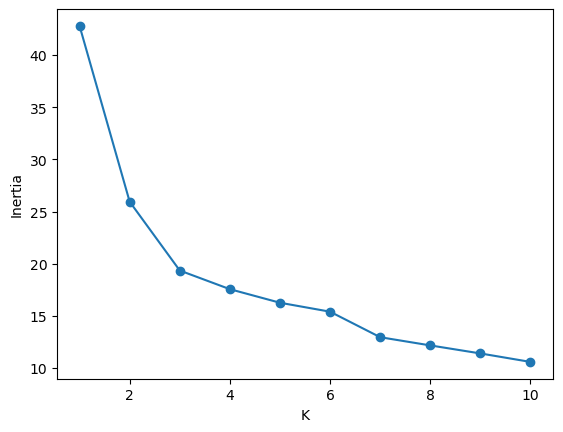

In [77]:
# Plot elbow curve
def eval_Kmeans(x, k, r):
    kmeans = KMeans(n_clusters=k, random_state=r, max_iter=500)
    kmeans.fit(x)
    return kmeans.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k+1)]
    plt.plot(range(1, 11), within_cluster_vars,marker='o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

    # Plot elbow curve using scaled dataset

elbow_Kmeans(df_scaled)

c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

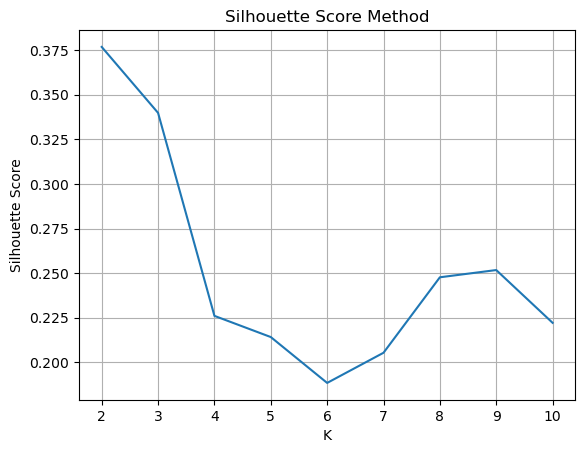

In [78]:
# Silhouette score method
kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(df_scaled, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('K')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()

Based on the elbow and silhouette score method choose a value for K.

## Fitting a K-Means Model with the selected K value

In [79]:
# Remember to set the random_state to rseed

# InitialiSe the KMeans model with 3 clusters and the random state
# Then fit the model to the normalised data
# Then predict the cluster for each data point
# Finally, add the cluster labels to the original DataFrame
kmeans = KMeans(n_clusters=3, random_state=rseed)

kmeans.fit(df_scaled)

clusters = kmeans.predict(df_scaled)

c:\Users\Urbanus Vermeulen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# Count the number of records in each cluster using the
# Pd.Series.value_counts method
cluster_records = pd.Series(clusters).value_counts()
print("Number of records in each cluster:")
print(cluster_records)

Number of records in each cluster:
0    87
2    45
1    35
Name: count, dtype: int64


In [81]:
# Check model performance with the silhouette coefficient
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Coefficient: {silhouette_avg:.2f}")


Silhouette Coefficient: 0.34


## Predictions

In [82]:
# Add the predicted cluster label column to the original dataframe
df['Cluster'] = clusters

# Since we have mapped dataframes in previous assignments, we can
# assign appropriate names to the clusters which could improve
# Readability and understanding of the data. And would make
# The legends more readable in visualisations.
cluster_names = {
    0: 'Deleveloping',
    1: 'Developed',
    2: 'Least Developed'
}

# Map the cluster names to the cluster numbers
df['Cluster'] = df['Cluster'].map(cluster_names)
print(df.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp          Cluster  
0       9.44        56.2       5.82    553  Least Developed  
1       4.49        76.3       1.65   4090     Deleveloping  
2      16.10        76.5       2.89   4460     Deleveloping  
3      22.40        60.1       6.16   3530  Least Developed  
4       1.44        76.8       2.13  12200     Deleveloping  


## Visualisation of clusters

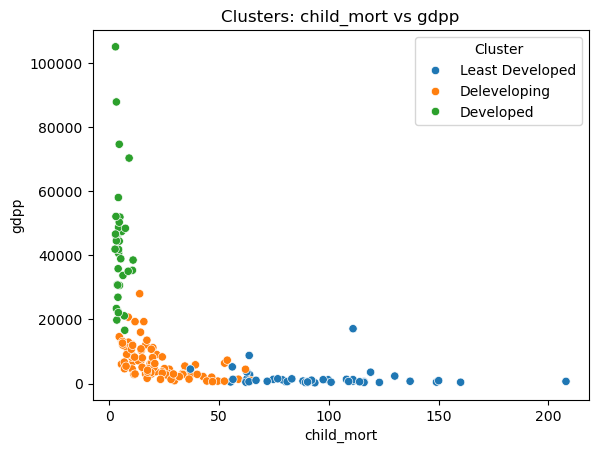

In [83]:
# Visualisation of clusters: child mortality vs gdpp
# Make use of a defined function to plot the scatter plots
def plot_clusters(df, x, y):
    plt.figure()
    sns.scatterplot(data=df, x=x, y=y, hue='Cluster')
    plt.title(f'Clusters: {x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend(title='Cluster')
    plt.show()



plot_clusters(df, 'child_mort', 'gdpp')



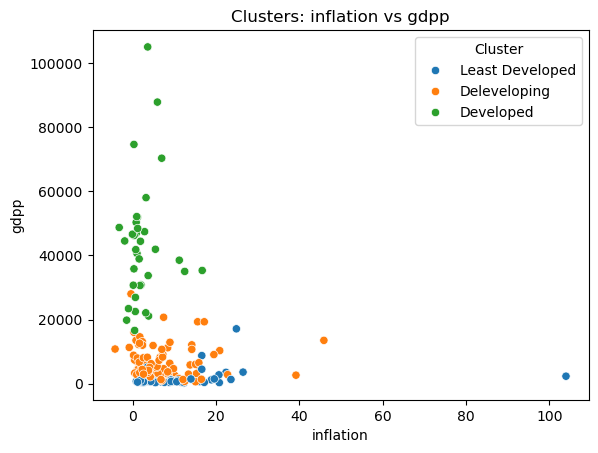

In [84]:
# Visualisation of clusters: inflation vs gdpp
plot_clusters(df, 'inflation', 'gdpp')

## Conclusions

Label the groups of countries in the plots you created based on child mortality, GDPP and inflation. You may use [terms](https://en.wikipedia.org/wiki/Developing_country#Terms_used_to_classify_countries) such as: least developed, developing and developed, or low, low-middle, upper-middle and high income. Alternatively, simply rank them from highest to lowest. Justify the labels you assign to each group.


**Answer here:**

**Choosing the appropriate K-value**:

When looking at the elbow curve figure, we can see a significant decrease in inertia between 3 and 4, where 1 to 2 and 2 to 3 were more significant. This means that either cluster(k) 3 or 4 will be the ideal cluster.

When we look at to the silhouette score method,3 scored the highest value between K 3 and K 4 Thus we can assume the best K value will be 3

**Silhouette coefficient:**

The silhouette coefficient is o.34, which is on the lower end. This means that overlapping takes place. However, this makes sense, as we are comparing gdpp of developed, developing, and least developed countries. In this situation, an even increase in child mortality makes sense as one cluster moves into the following one, like developing being a bit inside of both developed and least developed. So, for this example, I believe 0.34 is well fitted for the data.

**Label justification:**

The clusters were assigned the following labels; 0 for developing, 1 for developed, and 2 for least developed. When looking at the graphs, 0 had the lowest and furthest spread, for child mortality vs gdpp it had the highest mortality rate and the lowest gdpp. Developing had moderate spread when comparing it to the other two clusters, which makes sense, it had a moderate child mortality rate, and a moderate inflation rate when compared to gdpp.  Developed had the lowest child mortality rate, and then the lowest inflation per gdpp. This justifies the labelling as it agrees with similar graphs done with global economic trends(Our World in Data, 2024; ResearchGate, 2023).



# References

Our World in Data. (2024). Child mortality rate vs. GDP per capita. Available at: https://ourworldindata.org/grapher/child-mortality-gdp-per-capita [Accessed 28 Feb. 2025].

ResearchGate. (2023). A scatter diagram showing the relationship between GDP growth rate and inflation rate. Available at: https://www.researchgate.net/figure/A-scatter-Diagram-Showing-the-Relationship-between-GDP-Growth-rate-and-Inflation-Rate_fig1_276267144 [Accessed 28 Feb. 2025].

